# Debugging splice junction modeling

## imports

In [48]:
import os
import yaml
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

import seaborn as sns
import matplotlib.pyplot as plt

from figutils import (
    cm,
    set_figure_style, 
)

set_figure_style()

FIGS_DIR = os.path.join("pdfs","debug_junctions")
os.makedirs(FIGS_DIR, exist_ok=True)

## data

In [49]:
# paths

ROOT = ".."
RAW_DIR = os.path.join(ROOT,"data","raw")
RESULTS_DIR = os.path.join(ROOT,"results")

config = yaml.safe_load(open(os.path.join(ROOT,"config","config.yaml"),"r"))
SINGLE_DIR = config["preprocessing"]["overfitting"]["single"]["output_dir"]
SAMPLES = config["preprocessing"]["overfitting"]["samples"]

interval_file = os.path.join(ROOT, SINGLE_DIR, "medium.bed")

pretrained_file = os.path.join(ROOT, SINGLE_DIR, "medium", "splice_junctions.npz")

raw_files = {
    s: os.path.join(ROOT, config["rnaseq"]["sf3b1mut"]["path"], "STAR", s, "paper_pass.SJ.out.tab")
    for s in SAMPLES
}

OUTPUT_DIR = "results/finetuning/alphagenome_pytorch/overfitting/single"
finetuned_file = os.path.join(ROOT, OUTPUT_DIR, "medium", "debug_splice_junctions__truncrope__origloss__predicted__pretrinit__float32", "splice_junctions.npz")

In [50]:
# loads

interval = pd.read_table(
    interval_file, header=None, names=["chrom", "start", "end"],
)

chrom_oi = interval["chrom"].iloc[0]
start_oi = interval["start"].iloc[0]
end_oi = interval["end"].iloc[0]
seq_len = end_oi - start_oi

pretrained = np.load(pretrained_file)

raw = pd.concat(
    [
        pd.read_table(
            f,
            header=None,
            names=[
                "chrom",
                "intron_start",
                "intron_end",
                "strand_code",
                "intron_motif",
                "annotated",
                "n_uniquely_mapped_reads",
                "n_multi_mapped_reads",
                "max_overhang",
            ],
        )
        .assign(
            sample=s,
            exon_start=lambda d: d["intron_start"] - 1,
            exon_end=lambda d: d["intron_end"] + 1,
            strand=lambda d: d["strand_code"].astype(str).map(
                {"0": ".", "1": "+", "2": "-"}
            ).fillna("."),
            count=lambda d: pd.to_numeric(
                d["n_uniquely_mapped_reads"], errors="coerce"
            )
        )
        .query(
            "chrom.str.contains('chr') & strand.isin(['+','-']) & count > 1"
        )
        for s, f in raw_files.items()
    ],
    ignore_index=True
)

finetuned = np.load(finetuned_file)

## contents

In [51]:
print(pretrained.files)
print(pretrained["junction_positions"].shape)
print(pretrained["junction_counts"].shape)

['junction_positions', 'junction_counts']
(4, 512)


(512, 512, 734)


In [52]:
print(finetuned.files)
print(finetuned["junction_positions"].shape)
print(finetuned["junction_counts"].shape)

['junction_positions', 'junction_counts']
(4, 512)
(512, 512, 4)


## preprocess raw junctions

In [53]:
def normalize_junctions(junc_df: pd.DataFrame) -> pd.DataFrame:
    df = junc_df.copy()

    # Step 1: CPM normalize
    total_reads = df["count"].sum()
    if total_reads > 0:
        df["cpm"] = (df["count"] / total_reads) * 1e6
    else:
        return df  # All zeros, return as-is

    # Step 2: Clip at 99.99th percentile
    threshold = float(np.percentile(df["cpm"], 99.99))
    df["clipped"] = np.minimum(df["cpm"], threshold)

    # Step 3: Scale by mean of nonzero values
    nonzero = df.loc[df["clipped"] > 0, "clipped"]
    if len(nonzero) > 0:
        mean_val = float(nonzero.mean())
        if mean_val > 0:
            df["scaled"] = df["clipped"] / mean_val

    return df

raw = raw.groupby("sample").apply(normalize_junctions).reset_index()

In [54]:
def junctions_to_junction_matrix(
    all_juncs_list: list[pd.DataFrame],
    cls_arr: np.ndarray,
    chrom: str,
    start: int,
    seq_len: int,
    max_splice_sites: int = 512,
) -> tuple[np.ndarray, np.ndarray]:
    n_samples = len(all_juncs_list)

    # Extract positions for each role from cls_arr columns
    # 0=Donor+, 1=Acceptor+, 2=Donor-, 3=Acceptor-
    pos_donor_pos = np.where(cls_arr[:, 0] > 0)[0][:max_splice_sites]
    pos_accept_pos = np.where(cls_arr[:, 1] > 0)[0][:max_splice_sites]
    neg_donor_pos = np.where(cls_arr[:, 2] > 0)[0][:max_splice_sites]
    neg_accept_pos = np.where(cls_arr[:, 3] > 0)[0][:max_splice_sites]

    def _pad(arr: np.ndarray) -> np.ndarray:
        out = np.full(max_splice_sites, -1, dtype=np.int32)
        out[: len(arr)] = arr
        return out

    positions = np.stack([
        _pad(pos_donor_pos),
        _pad(pos_accept_pos),
        _pad(neg_donor_pos),
        _pad(neg_accept_pos),
    ])  # (4, max_splice_sites)

    matrix = np.zeros(
        (max_splice_sites, max_splice_sites, 2 * n_samples), dtype=np.float32
    )

    # Build reverse-lookup maps: 0-based relative position → index in positions array
    pos_donor_map = {int(p): i for i, p in enumerate(pos_donor_pos)}
    pos_accept_map = {int(p): i for i, p in enumerate(pos_accept_pos)}
    neg_donor_map = {int(p): i for i, p in enumerate(neg_donor_pos)}
    neg_accept_map = {int(p): i for i, p in enumerate(neg_accept_pos)}

    end = start + seq_len

    for s, junc_df in enumerate(all_juncs_list):
        mask = (
            (junc_df["chrom"] == chrom)
            & (junc_df["exon_start"] > start)   # 1-based exon_start > start → ≥ start+1
            & (junc_df["exon_start"] <= end)
            & (junc_df["exon_end"] > start)
            & (junc_df["exon_end"] <= end)
        )
        local = junc_df.loc[mask]
        if local.empty:
            continue

        for _, junc in local.iterrows():
            # 1-based exon coords → 0-based relative index
            d_rel = int(junc["exon_start"]) - 1 - start
            a_rel = int(junc["exon_end"]) - 1 - start
            count = float(junc["count"])
            strand = junc["strand"]

            if strand == "+":
                d_idx = pos_donor_map.get(d_rel)
                a_idx = pos_accept_map.get(a_rel)
                if d_idx is not None and a_idx is not None:
                    matrix[d_idx, a_idx, s] += count
            elif strand == "-":
                d_idx = neg_donor_map.get(d_rel)
                a_idx = neg_accept_map.get(a_rel)
                if d_idx is not None and a_idx is not None:
                    matrix[d_idx, a_idx, n_samples + s] += count

    return positions, matrix


# Reconstruct cls_arr (seq_len, 4) from pretrained junction_positions (4, 512)
# Positions == -1 are padding; skip them
jp = pretrained["junction_positions"]  # (4, 512)
cls_arr = np.zeros((seq_len, 4), dtype=np.float32)
for col in range(4):
    valid = jp[col][jp[col] >= 0]
    cls_arr[valid, col] = 1.0

# Per-sample DataFrames using scaled (CPM-normalized) counts
all_juncs_list = []
for s in SAMPLES:
    df = raw[raw["sample"] == s].copy()
    df = df.assign(count=df["scaled"].fillna(0))
    all_juncs_list.append(df)

raw_junction_positions, raw_junction_counts = junctions_to_junction_matrix(
    all_juncs_list=all_juncs_list,
    cls_arr=cls_arr,
    chrom=chrom_oi,
    start=start_oi,
    seq_len=seq_len,
    max_splice_sites=512,
)

print(raw_junction_positions.shape)   # (4, 512)
print(raw_junction_counts.shape)      # (512, 512, len(SAMPLES)*2)

(4, 512)
(512, 512, 4)


## do the distributions of values match?

### total number of non-zero junctions

In [55]:
arr_juncs = {}

In [56]:
idx_oi = 139
n_samples = pretrained["junction_counts"].shape[2] // 2
X = pretrained["junction_counts"][:,:,[idx_oi, n_samples + idx_oi]] # positive and negative strand predictions
arr_juncs["pretrained"] = X
X = X[X>0]
len(X)

87714

In [57]:
idx_oi = 0
n_samples = finetuned["junction_counts"].shape[2] // 2
X = finetuned["junction_counts"][:,:,[idx_oi, n_samples + idx_oi]] # positive and negative strand predictions
arr_juncs["finetuned"] = X
X = X[X>0]
len(X)

40662

In [58]:
idx_oi = 0
n_samples = raw_junction_counts.shape[2] // 2
X = raw_junction_counts[:,:,[idx_oi, n_samples + idx_oi]] # positive and negative strand predictions
arr_juncs["raw"] = X
X = X[X>0]
len(X)

45

### distributions of predicted splice junctions

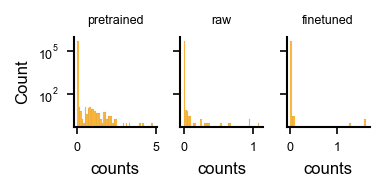

In [59]:
X = pd.concat([
    pd.DataFrame({"data_type": k, "counts": v.ravel()}) 
    for k, v in arr_juncs.items()
    ], 
    ignore_index=True
)

g = sns.displot(
    kind="hist",
    data=X,
    x="counts",
    color="orange",
    col="data_type", col_order=["pretrained","raw","finetuned"],
    bins=50,
    common_bins=False,
    facet_kws=dict(sharex=False),
    height=3.25*cm, aspect=0.7
)

g.set(yscale="log")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.title.set_size(6)
    
g.fig.savefig(os.path.join(FIGS_DIR,"junction_count_distr-hist.pdf"), bbox_inches="tight", dpi=200)

plt.show()

## junction counts vs genomic position

In [60]:
def junctions_to_tidy(
    junction_positions: np.ndarray,  # (4, max_splice_sites)
    junction_counts: np.ndarray,      # (max_splice_sites, max_splice_sites, n_samples*2)
    genomic_start: int = 0,
) -> pd.DataFrame:
    """
    Unpacks a junction count matrix into a tidy DataFrame.
    
    Columns: donor_pos, acceptor_pos, strand, sample_idx, count
    Positions are 0-based relative to the sequence window (+ genomic_start for absolute coords).
    Rows with count == 0 are dropped.
    """
    n_samples = junction_counts.shape[2] // 2
    records = []

    # strand_offset: 0=Donor+/Acceptor+, 2=Donor-/Acceptor-
    for strand, ch_offset, strand_offset in [("+", 0, 0), ("-", n_samples, 2)]:
        counts_strand = junction_counts[:, :, ch_offset : ch_offset + n_samples]  # (512,512,n_samples)
        d_idx, a_idx, s_idx = np.where(counts_strand > 0)

        donor_positions = junction_positions[strand_offset]      # Donor+/Donor-
        acceptor_positions = junction_positions[strand_offset + 1]  # Acceptor+/Acceptor-

        for di, ai, si in zip(d_idx, a_idx, s_idx):
            dp = int(donor_positions[di])
            ap = int(acceptor_positions[ai])
            if dp < 0 or ap < 0:  # padding sentinels
                continue
            records.append({
                "donor_pos": dp + genomic_start,
                "acceptor_pos": ap + genomic_start,
                "junction_len": abs(ap - dp),
                "strand": strand,
                "sample_idx": int(si),
                "count": float(counts_strand[di, ai, si]),
            })

    return pd.DataFrame(records)


tidy = {
    "pretrained": junctions_to_tidy(
        pretrained["junction_positions"], pretrained["junction_counts"], start_oi
    ).assign(idx_oi=139).pipe(
        lambda d: d[d["sample_idx"] == 139]  # pick the same sample used above
    ),
    "finetuned": junctions_to_tidy(
        finetuned["junction_positions"], finetuned["junction_counts"], start_oi
    ).assign(idx_oi=0).pipe(
        lambda d: d[d["sample_idx"] == 0]
    ),
    "raw": junctions_to_tidy(
        raw_junction_positions, raw_junction_counts, start_oi
    ).pipe(
        lambda d: d[d["sample_idx"] == 0]
    ),
}

for name, df in tidy.items():
    print(name, df.shape)
    display(df.head(3))


pretrained (87714, 7)


,donor_pos,acceptor_pos,junction_len,strand,sample_idx,count,idx_oi
139,89118171,89097538,20633,+,139,0.000022,139
506,89118171,89121284,3113,+,139,0.000143,139
873,89118171,89135946,17775,+,139,0.000077,139


finetuned (40662, 7)


,donor_pos,acceptor_pos,junction_len,strand,sample_idx,count,idx_oi
0,89145944,89097538,48406,+,0,8.797090e-08,0
2,89145944,89148505,2561,+,0,4.616389e-09,0
4,89145944,89148524,2580,+,0,1.807100e-10,0


raw (45, 6)


,donor_pos,acceptor_pos,junction_len,strand,sample_idx,count
0,89146608,89148524,1916,+,0,0.013768
2,89146608,89149264,2656,+,0,0.172098
4,89148573,89149264,691,+,0,0.137678


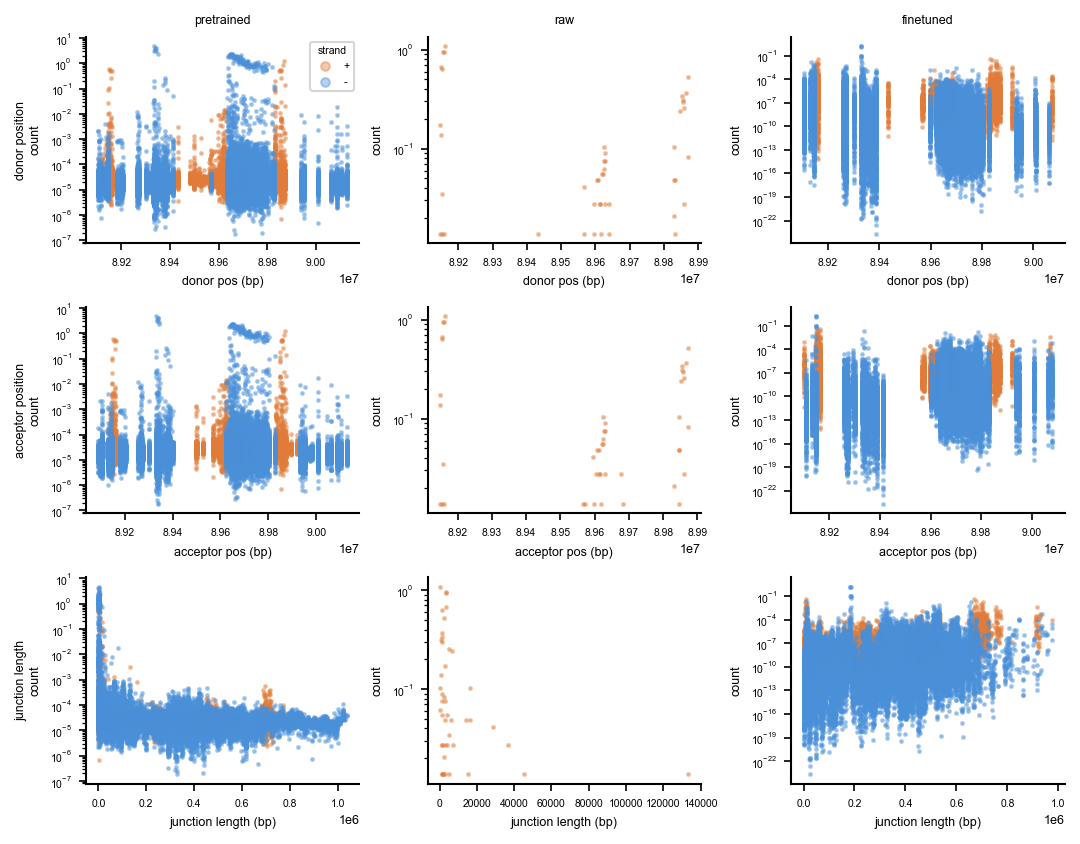

In [61]:
fig, axes = plt.subplots(
    3, 3,
    figsize=(18 * cm, 14 * cm),
    constrained_layout=True,
)

data_order = ["pretrained", "raw", "finetuned"]
palette = {"+": "#e07b39", "-": "#4a90d9"}

for col, name in enumerate(data_order):
    df = tidy[name]
    ax_don = axes[0, col]
    ax_acc = axes[1, col]
    ax_len = axes[2, col]

    for strand, grp in df.groupby("strand"):
        c = palette[strand]
        ax_don.scatter(
            grp["donor_pos"], grp["count"],
            s=2, alpha=0.4, color=c, rasterized=True, label=strand,
        )
        ax_acc.scatter(
            grp["acceptor_pos"], grp["count"],
            s=2, alpha=0.4, color=c, rasterized=True,
        )
        ax_len.scatter(
            grp["junction_len"], grp["count"],
            s=2, alpha=0.4, color=c, rasterized=True,
        )

    ax_don.set_title(name, fontsize=6)
    ax_don.set_xlabel("donor pos (bp)", fontsize=6)
    ax_acc.set_xlabel("acceptor pos (bp)", fontsize=6)
    ax_len.set_xlabel("junction length (bp)", fontsize=6)
    for ax in (ax_don, ax_acc, ax_len):
        ax.set_ylabel("count", fontsize=6)
        ax.tick_params(labelsize=5)
        ax.set_yscale("log")

axes[0, 0].legend(title="strand", fontsize=5, title_fontsize=5, markerscale=3)

row_labels = ["donor position", "acceptor position", "junction length"]
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(f"{label}\ncount", fontsize=6)

fig.savefig(os.path.join(FIGS_DIR, "junction_counts_vs_position-scatter.pdf"), bbox_inches="tight", dpi=200)
plt.show()


In [62]:
join_cols = ["donor_pos", "acceptor_pos", "strand"]

X = (
    tidy["pretrained"][join_cols + ["count"]].rename(columns={"count": "count_pretrained"})
    .merge(
        tidy["raw"][join_cols + ["count"]].rename(columns={"count": "count_raw"}),
        on=join_cols, how="inner",
    )
    .merge(
        tidy["finetuned"][join_cols + ["count"]].rename(columns={"count": "count_finetuned"}),
        on=join_cols, how="inner",
    )
    .assign(junction_len=lambda d: (d["acceptor_pos"] - d["donor_pos"]).abs())
)

print(X.shape)
X.head()

(45, 7)


,donor_pos,acceptor_pos,strand,count_pretrained,count_raw,count_finetuned,junction_len
0,89146608,89148524,+,0.027220,0.013768,1.945153e-11,1916
1,89146608,89149264,+,0.087013,0.172098,1.355592e-09,2656
2,89148573,89149264,+,0.105380,0.137678,6.722923e-08,691
3,89149412,89153042,+,0.587678,0.667740,2.522308e-12,3630
4,89151905,89153042,+,0.004884,0.013768,5.556275e-11,1137


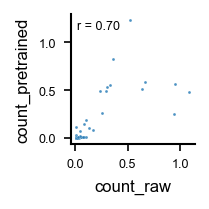

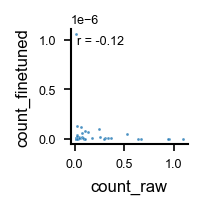

In [63]:
for y in ["count_pretrained", "count_finetuned"]:

    g = sns.relplot(
        kind="scatter",
        data=X,
        x="count_raw",
        y=y,
        s=2,
        alpha=0.8,
        height=3.5*cm,
        aspect=1
    )

    d = X[["count_raw", y]].dropna()
    r, p = pearsonr(d["count_raw"], d[y])

    ax = g.ax
    ax.text(
        0.05, 0.95,
        f"r = {r:.2f}",
        transform=ax.transAxes,
        ha="left",
        va="top"
    )

    plt.show()